# LeetCode #513: Find Bottom Left Tree Value

https://leetcode.com/problems/find-bottom-left-tree-value/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (DFS track depth)** | $O(n)$ | $O(h)$ |
| **Optimal: BFS Level Order ★** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (DFS track depth)
DFS while tracking current depth; update answer whenever a node is at a new maximum depth and is the leftmost (first) node seen at that depth. Requires tracking depth separately.

### Optimal: BFS Level Order ★
BFS processes nodes level by level. Record the first node of each level as the candidate answer. After exhausting the queue, the last recorded first-of-level is the bottom-left value.

**Why this is better than Brute Force:** No depth tracking needed; the queue naturally enforces left-to-right ordering within each level.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 10^4]$.
* $-2^{31} \le$ Node.val $\le 2^{31} - 1$

## Solutions

### C#

In [ ]:
public int FindBottomLeftValue(TreeNode root) {
    var queue = new Queue<TreeNode>();
    queue.Enqueue(root);
    int result = root.val;
    while (queue.Count > 0) {
        // Record the first node of this level as the candidate answer
        result = queue.Peek().val;
        int sz = queue.Count;
        while (sz-- > 0) {
            var node = queue.Dequeue();
            // Enqueue left before right to preserve left-to-right order
            if (node.left  != null) queue.Enqueue(node.left);
            if (node.right != null) queue.Enqueue(node.right);
        }
    }
    return result;
}

### Python

In [ ]:
from collections import deque

def findBottomLeftValue(self, root: Optional[TreeNode]) -> int:
    queue = deque([root])
    result = root.val
    while queue:
        # Record leftmost node of current level
        result = queue[0].val
        for _ in range(len(queue)):
            node = queue.popleft()
            # Left before right preserves left-to-right ordering
            if node.left:  queue.append(node.left)
            if node.right: queue.append(node.right)
    return result

### Go

In [ ]:
func findBottomLeftValue(root *TreeNode) int {
    queue := []*TreeNode{root}
    result := root.Val
    for len(queue) > 0 {
        // Record leftmost node of current level
        result = queue[0].Val
        sz := len(queue)
        for i := 0; i < sz; i++ {
            node := queue[i]
            // Left before right preserves left-to-right ordering
            if node.Left  != nil { queue = append(queue, node.Left) }
            if node.Right != nil { queue = append(queue, node.Right) }
        }
        queue = queue[sz:]
    }
    return result
}

### Rust

In [ ]:
pub fn find_bottom_left_value(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
    let mut queue = std::collections::VecDeque::new();
    if let Some(r) = root { queue.push_back(r); }
    let mut result = 0i32;
    while !queue.is_empty() {
        // Record leftmost node of current level
        result = queue.front().unwrap().borrow().val;
        for _ in 0..queue.len() {
            let node = queue.pop_front().unwrap();
            let (l, r) = { let b = node.borrow(); (b.left.clone(), b.right.clone()) };
            // Left before right preserves left-to-right ordering
            if let Some(l) = l { queue.push_back(l); }
            if let Some(r) = r { queue.push_back(r); }
        }
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** root = [2,1,3]
Level 0: result=2. Level 1: result=1 (leftmost of [1,3]). Queue empties. Return **1**.

**2. Slightly Complex**
**Input:** root = [1,2,3,4,null,5,6,null,null,7]
Level 0: result=1. Level 1: result=2. Level 2: result=4. Level 3: result=7 (only node). Return **7** — deepest leftmost node.

**3. Edge Case: Time Factor**
**Input:** A right-skewed tree [1,null,2,null,3,...,null,n]
BFS visits every node one at a time (only one node per level). After $n$ iterations the result equals the root value 1 since every level has exactly one node — the single node IS the leftmost of its level. Return root.val = **1**.

**4. Edge Case: Space Factor**
**Input:** A complete binary tree with $n = 10^4$ nodes
The last level has up to $n/2 = 5000$ nodes all enqueued simultaneously, consuming $O(n)$ queue space at peak. The bottom-left is the leftmost node of that last level.

**5. Almost-Impossible but Plausible**
**Input:** root = [2147483647] (single node, max int value)
Single BFS iteration: result = 2147483647, no children enqueued. Return **2147483647** — edge for 32-bit signed integer overflow checks.

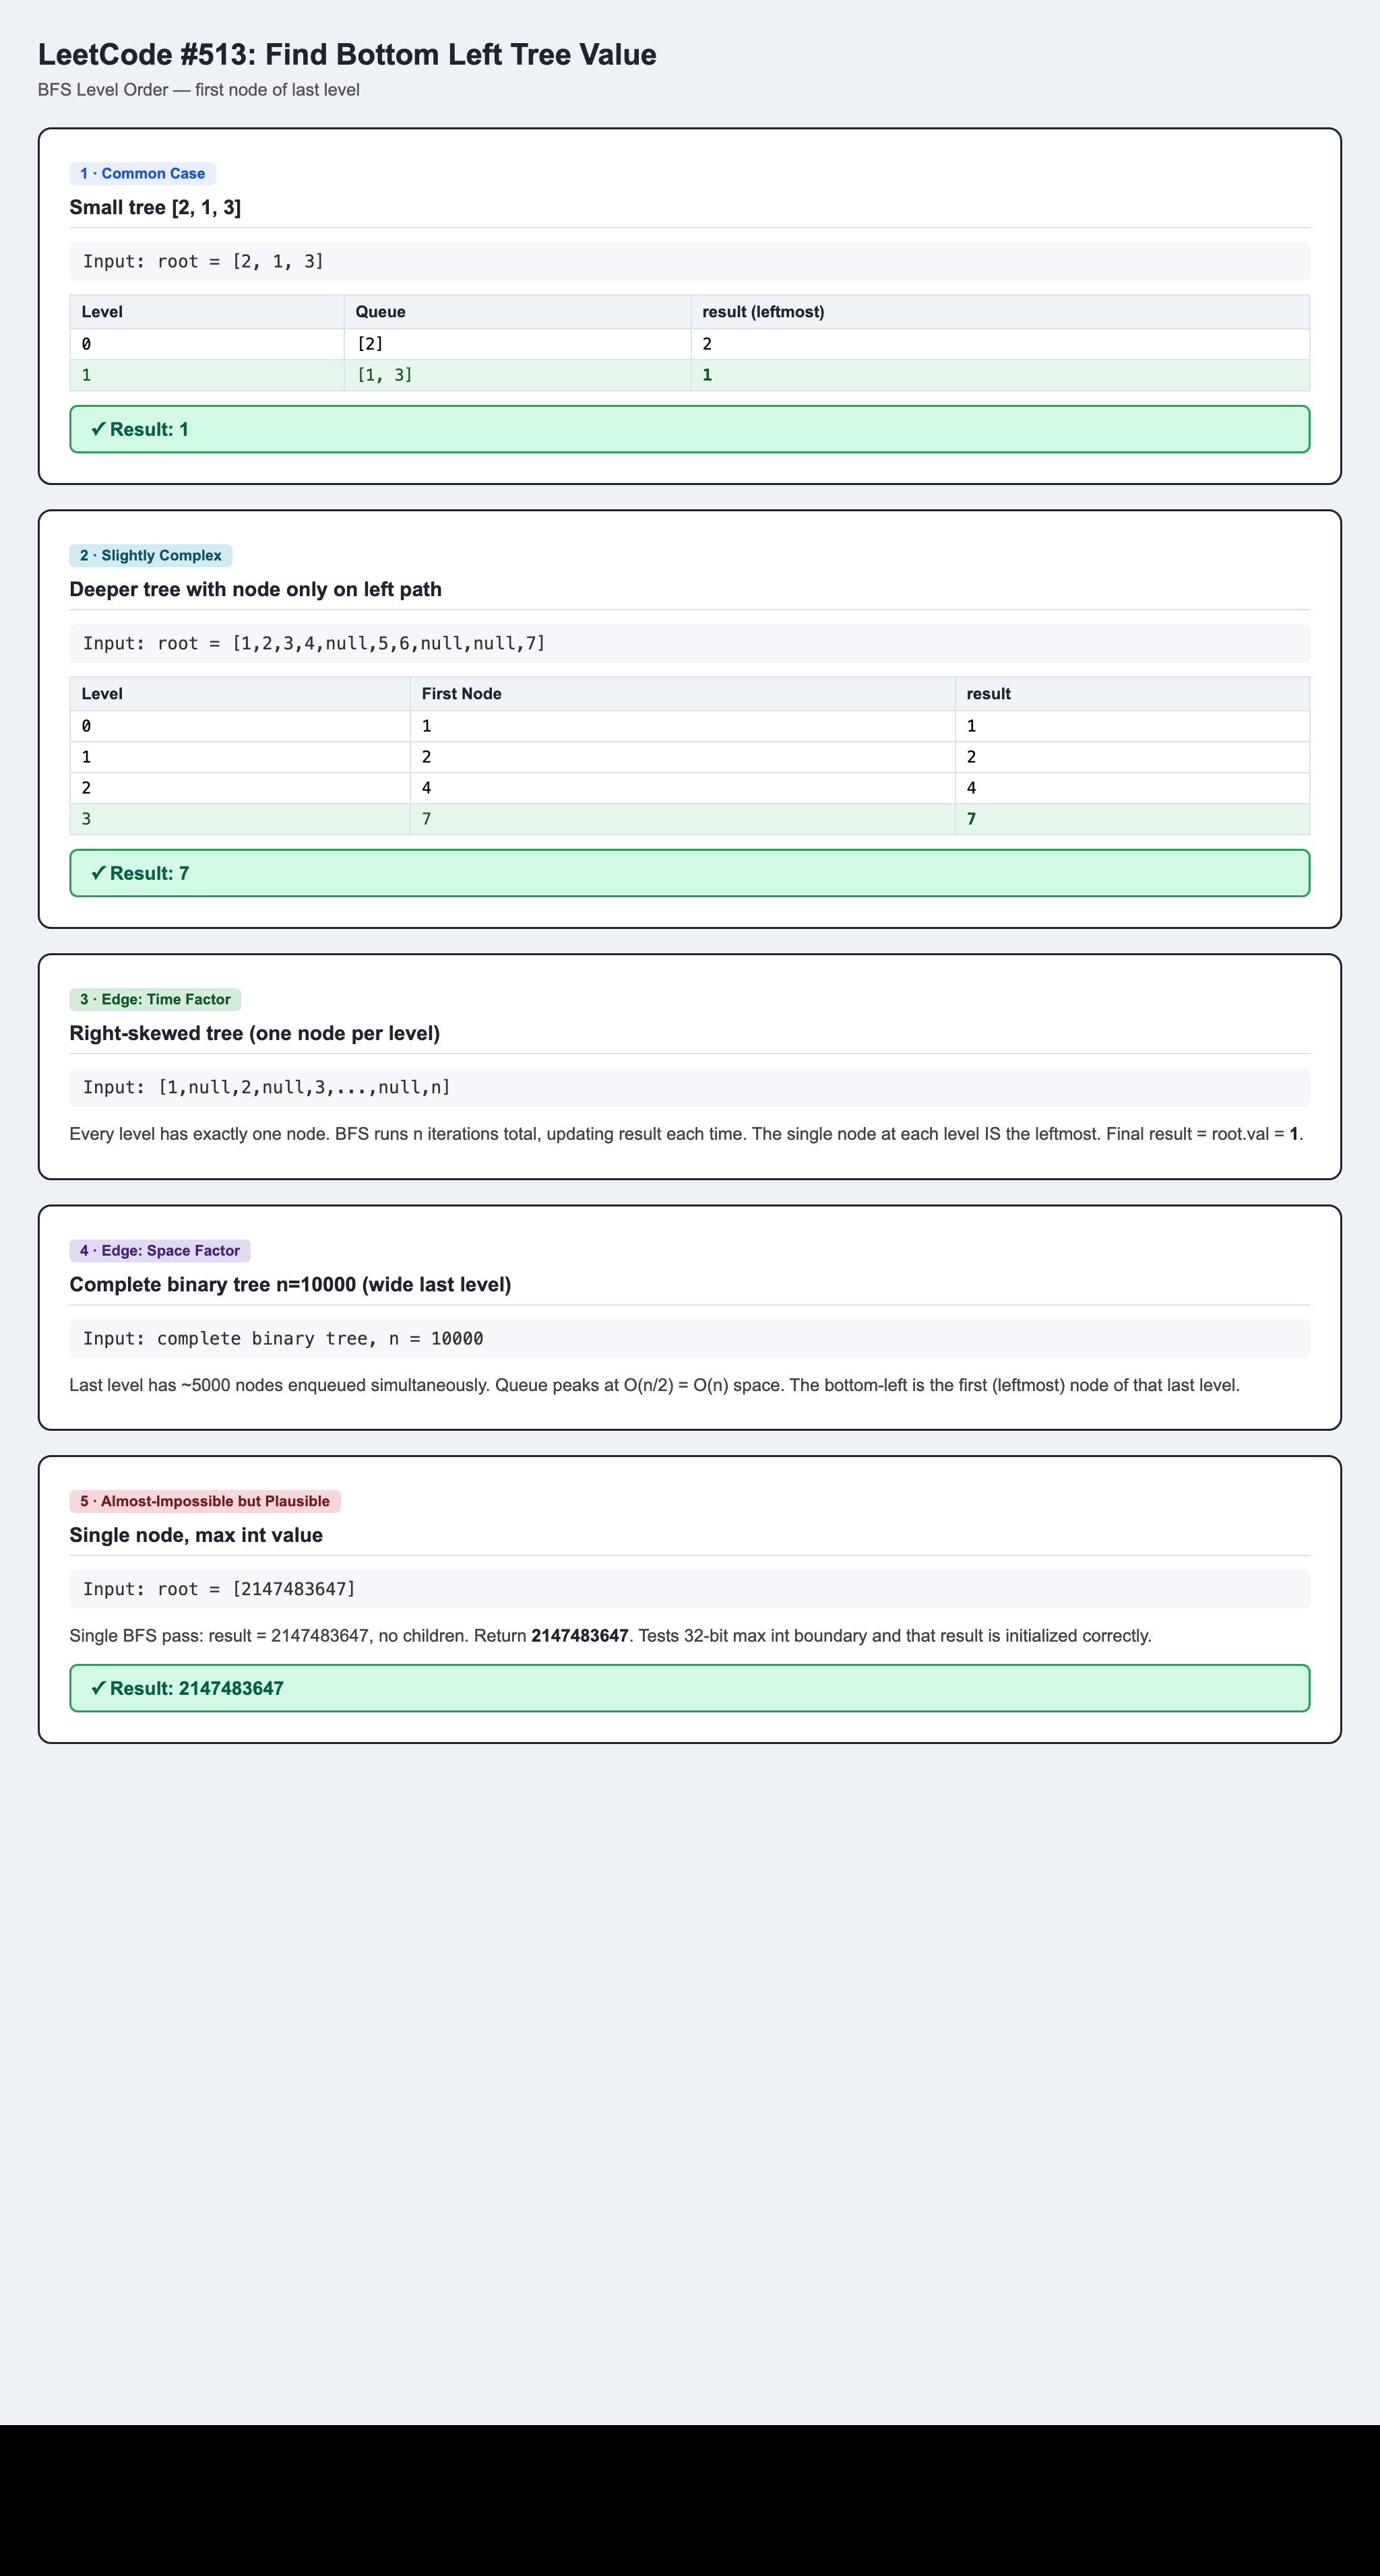